In [1]:
import openai
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import re
import time
from openai import OpenAI
import json
import pickle
import pandas as pd
import os

sys.path += ['../src/']
# Set a global seed for reproducibility 
# GLOBAL_SEED = 42
# np.random.seed(GLOBAL_SEED)
# random.seed(GLOBAL_SEED)

#from model import *
import modelWithPersonality as mod
from utils import *

In [2]:
path_exp = '../results/experiments/'

print(f"Current working directory: {os.getcwd()}")
print(f"Path to experiment files: {path_exp}")
print(os.path.abspath("../results/experiments"))

Current working directory: c:\Users\Sidney\OneDrive\文件\FYP\FYP\gpt_agents-master\notebooks
Path to experiment files: ../results/experiments/
c:\Users\Sidney\OneDrive\文件\FYP\FYP\gpt_agents-master\results\experiments


In [3]:
openai.__version__

'1.58.1'

In [4]:
# set simulation parameters
# disabling seed in this case
# isolate personality from seeding
#seed = 0
#np.random.seed(seed)
seed = None
noise_mean = 0
noise_sd = 1/4
temperature = 1
memory = 3
instruction_type = 'original_30-50w'
n_agents = 5
n_steps = 50
#n_steps = 5
gpt_model="gpt-3.5-turbo-0125"
#gpt_model="gpt-3.5-turbo-1106"

In [5]:
np.random.seed(1)
print(np.random.rand(3))

[4.17022005e-01 7.20324493e-01 1.14374817e-04]


# Positive feedback

In [8]:
expmnt_num = 0
feedback='pos'
expmnt_num = check_existing_file(path_exp, expmnt_num, feedback, instruction_type, temperature, memory, n_steps, n_agents, gpt_model)

Checking files in absolute path: c:\Users\Sidney\OneDrive\文件\FYP\FYP\gpt_agents-master\results\experiments
Looking for file: c:\Users\Sidney\OneDrive\文件\FYP\FYP\gpt_agents-master\results\experiments\expmnt_results_pos_original_30-50w_num_0_temp_1_memory_3_ntime_50_nagents_5_model_gpt-3-5-turbo-0125.csv
File expmnt_results_pos_original_30-50w_num_0_temp_1_memory_3_ntime_50_nagents_5_model_gpt-3-5-turbo-0125.csv does not exist. Safe to proceed with experiment number 0.


In [9]:
#op =original positive
p_array_op, pe_agents_time_op, rewards_agents_time_op, messages_list_op  = mod.run_experiment(seed,\
                expmnt_num, noise_mean, noise_sd, temperature, memory=memory, gpt_model=gpt_model, n_steps=n_steps, n_agents=n_agents,
                feedback=feedback, instruction_type=instruction_type, prints_on=True,\
                save_res_bool=True, path_exp=path_exp)

Experiment Fingerprints: b6d4122e8155c6a66e45d4f074371de4
 
 Time: 0, agent: 0, personality: risk-adverse 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "I will start with a conservative prediction close to the initial price, considering stability and lack of information from previous time periods",\n  "predictedValue": 50.00\n}'}
 
 Time: 0, agent: 1, personality: risk-adverse 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n    "reasoning": "I will start with a middle-of-the-road prediction to avoid extreme errors in the initial period.",\n    "predictedValue": 50.00\n}'}
 
 Time: 0, agent: 2, personality: risk-adverse 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "For the initial prediction, I will start

In [5]:
feedback='pos'
for i in range(1, 11):
    expmnt_num = check_existing_file(path_exp, i, feedback, instruction_type, temperature, memory, n_steps, n_agents, gpt_model)
    p_array_op, pe_agents_time_op, rewards_agents_time_op, messages_list_op  = mod.run_experiment(seed,\
                expmnt_num, noise_mean, noise_sd, temperature, memory=memory, gpt_model=gpt_model, n_steps=n_steps, n_agents=n_agents,
                feedback=feedback, instruction_type=instruction_type, prints_on=True,\
                save_res_bool=True, path_exp=path_exp)

Checking files in absolute path: c:\Users\Sidney\OneDrive\文件\FYP\FYP\gpt_agents-master\results\experiments
Looking for file: c:\Users\Sidney\OneDrive\文件\FYP\FYP\gpt_agents-master\results\experiments\expmnt_results_pos_original_30-50w_num_1_temp_1_memory_3_ntime_50_nagents_5_model_gpt-3-5-turbo-0125.csv
File expmnt_results_pos_original_30-50w_num_1_temp_1_memory_3_ntime_50_nagents_5_model_gpt-3-5-turbo-0125.csv does not exist. Safe to proceed with experiment number 1.
Experiment Fingerprints: b6d4122e8155c6a66e45d4f074371de4
 
 Time: 0, agent: 0, personality: risk-seeking 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "Initiating with an optimistic outlook, expecting positive market dynamics to set an upward trend.",\n  "predictedValue": 40.50\n}'}
 
 Time: 0, agent: 1, personality: risk-seeking 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}

In [10]:
pe_agents_time_op.shape

(5, 50)

Text(0.5, 0, 'Time step')

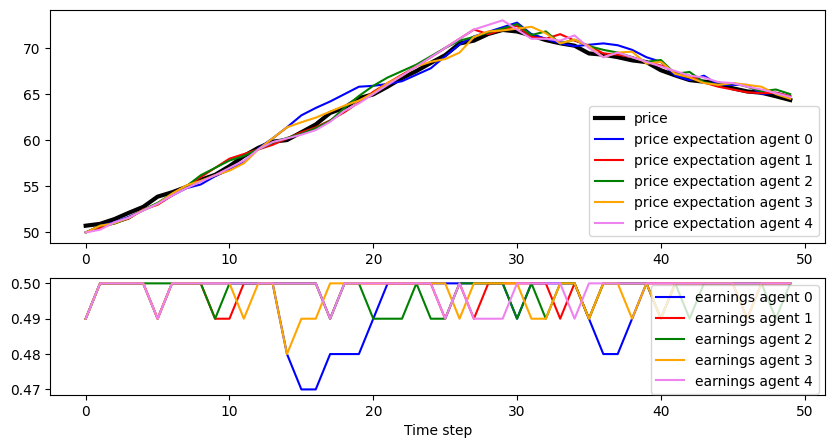

In [11]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 5), gridspec_kw={'height_ratios': [2, 1]})
colors = ["blue","red","green","orange","violet","cyan","gold"]

axes[0].plot(p_array_op,label="price",color="black",linewidth = 3)
for i in range(n_agents):
    axes[0].plot(pe_agents_time_op[i,:],label="price expectation agent "+str(i),color=colors[i])
    axes[1].plot(rewards_agents_time_op[i,:],label="earnings agent "+str(i),color=colors[i])

#axes[0].set_ylim(0,100)
axes[0].legend()
axes[1].legend()

axes[1].set_xlabel("Time step")
# axes[0].set_xticks(range(n_steps))
# axes[1].set_xticks(range(n_steps))

Seed = 0 
First fingerprint = 17ea0e8cd5950b3ad6a70158552235d5
Second fingerprint = 17ea0e8cd5950b3ad6a70158552235d5

In [11]:
# df = pd.read_csv("../results/experiments/expmnt_results_pos_original_30-50w_num_1_temp_1_ntime_50_nagents_5.csv")
df = pd.read_csv("../results/experiments/expmnt_results_pos_original_30-50w_num_1_temp_1_memory_3_ntime_50_nagents_5_model_gpt-3-5-turbo-0125.csv")

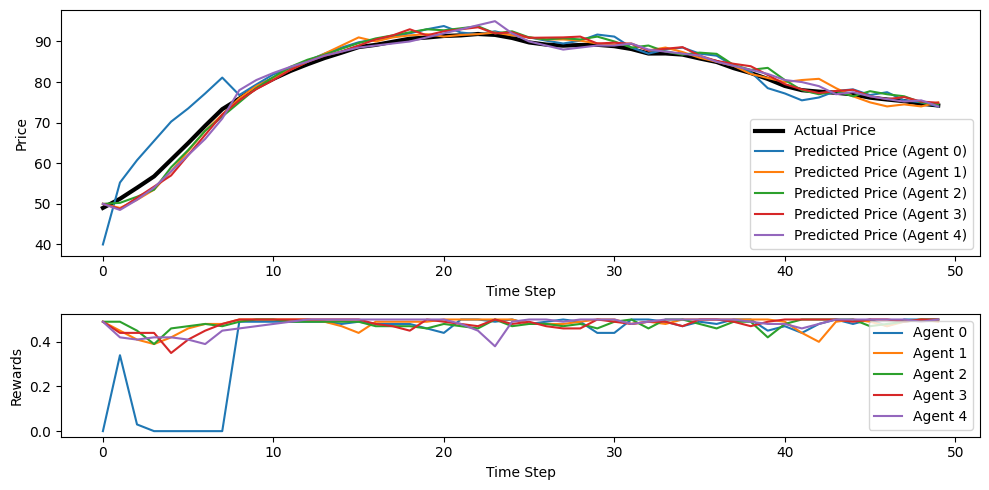

In [12]:
# Create figure and subplots
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 5), gridspec_kw={'height_ratios': [2, 1]})

# Plot actual and predicted prices over time_step
axs[0].plot(df['time_step'], df['actual_price'], label='Actual Price', color="black",linewidth = 3)
for agent_id, group in df.groupby('agent_id'):
    axs[0].plot(group['time_step'], group['predicted_price'], label=f'Predicted Price (Agent {agent_id})')
axs[0].set_xlabel('Time Step')
axs[0].set_ylabel('Price')
axs[0].legend()

# Plot rewards by agent_id over time_step
for agent_id, group in df.groupby('agent_id'):
    axs[1].plot(group['time_step'], group['rewards'], label=f'Agent {agent_id}')
axs[1].set_xlabel('Time Step')
axs[1].set_ylabel('Rewards')
axs[1].legend()

plt.tight_layout()
plt.show()

# Negative feedback

In [10]:
expmnt_num = 1
feedback='neg'
expmnt_num = check_existing_file(path_exp, expmnt_num, feedback, instruction_type, temperature, memory, n_steps, n_agents, gpt_model)

File expmnt_results_neg_original_30-50w_num_1_temp_1_memory_3_ntime_50_nagents_5_model_gpt-3-5-turbo-0125.csv does not exist. Safe to proceed.


In [11]:
#on =original negative
p_array_on, pe_agents_time_on, rewards_agents_time_on, messages_list_on  = mod.run_experiment(seed,\
                expmnt_num, noise_mean, noise_sd, temperature, memory=memory, gpt_model=gpt_model, n_steps=n_steps, n_agents=n_agents,
                feedback=feedback, instruction_type=instruction_type, prints_on=True,\
                save_res_bool=True, path_exp=path_exp)

 
 Time: 0, agent: 0 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "I will start with a moderate initial prediction based on the historical data available for the product. I will consider the past trends and the general market condition for my initial estimate.",\n  "predictedValue": 50.00\n}'}
 
 Time: 0, agent: 1 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "I will start with a moderate price prediction to assess the market response. I will consider typical demand and supply factors for this product.",\n  "predictedValue": 50.00\n}'}
 
 Time: 0, agent: 2 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "As this is the very first period, we don\'t have historical prices to base our predict

In [5]:
feedback='neg'
for i in range(1, 11):
    expmnt_num = check_existing_file(path_exp, i, feedback, instruction_type, temperature, memory, n_steps, n_agents, gpt_model)
    p_array_op, pe_agents_time_op, rewards_agents_time_op, messages_list_op  = mod.run_experiment(seed,\
                expmnt_num, noise_mean, noise_sd, temperature, memory=memory, gpt_model=gpt_model, n_steps=n_steps, n_agents=n_agents,
                feedback=feedback, instruction_type=instruction_type, prints_on=True,\
                save_res_bool=True, path_exp=path_exp)

Checking files in absolute path: c:\Users\Sidney\OneDrive\文件\FYP\FYP\gpt_agents-master\results\experiments
Looking for file: c:\Users\Sidney\OneDrive\文件\FYP\FYP\gpt_agents-master\results\experiments\expmnt_results_neg_original_30-50w_num_1_temp_1_memory_3_ntime_50_nagents_5_model_gpt-3-5-turbo-0125.csv
File expmnt_results_neg_original_30-50w_num_1_temp_1_memory_3_ntime_50_nagents_5_model_gpt-3-5-turbo-0125.csv does not exist. Safe to proceed with experiment number 1.
Experiment Fingerprints: c4792c29c11757058fe8fbb03009a9e6
 
 Time: 0, agent: 0, personality: risk-seeking 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n    "reasoning": "As a risk-seeking advisor, I aim to predict higher prices when positive market trends are observed.",\n    "predictedValue": 45.00\n}'}
 
 Time: 0, agent: 1, personality: risk-seeking 

{'role': 'user', 'content': 'This is the first time step, give an initial price predic

Text(0.5, 0, 'Time step')

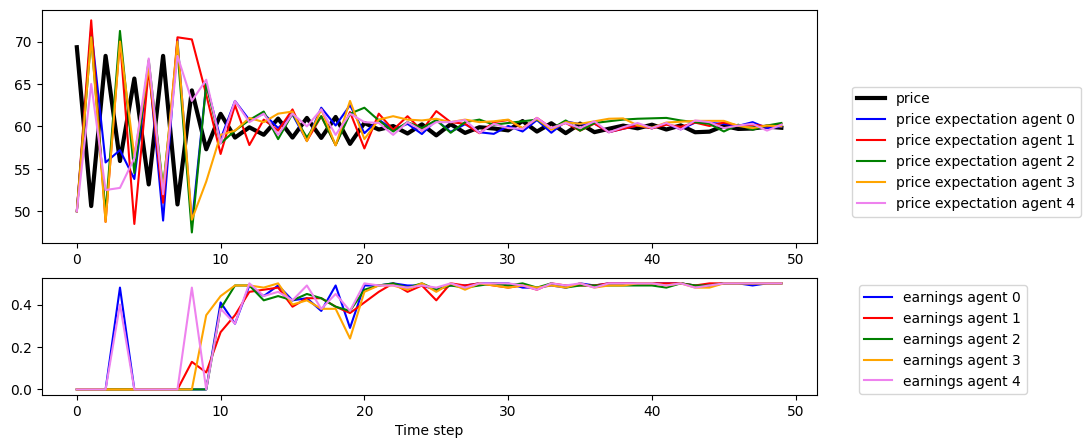

In [12]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 5), gridspec_kw={'height_ratios': [2, 1]})
colors = ["blue","red","green","orange","violet","cyan","gold"]

axes[0].plot(p_array_on,label="price",color="black",linewidth = 3)
for i in range(n_agents):
    axes[0].plot(pe_agents_time_on[i,:],label="price expectation agent "+str(i),color=colors[i])
    axes[1].plot(rewards_agents_time_on[i,:],label="earnings agent "+str(i),color=colors[i])

#axes[0].set_ylim(0,100)
axes[0].legend(bbox_to_anchor=(1.35, 0.7))
axes[1].legend(bbox_to_anchor=(1.28, 1))

axes[1].set_xlabel("Time step")
# axes[0].set_xticks(range(n_steps))
# axes[1].set_xticks(range(n_steps))